# Linear Cox with LLM-extracted chief complaint information at main-analysis demographic levels

This notebook fits simple linear Cox models using the same demographic families and level definitions as the main analysis pipeline:

- `gender` with reference `F`
- `race` with reference `White`
- `language` with reference `English`

For each dataset/outcome/family, it fits two models:

1. `structured`: family level indicators + basic structured variables.
2. `linear_cox_plus_llm_extracted`: `structured` + LLM-extracted chief complaint content variables + a clarity score.

No embeddings, TF-IDF, or SVD text features are used. The goal is a readable linear-Cox counterpart to the main pipeline's structured vs complaint-context comparison.


In [1]:
from pathlib import Path
from json import JSONDecoder
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.duration.hazard_regression import PHReg
from numpy.linalg import LinAlgError
from scipy.linalg import qr
from sklearn.impute import SimpleImputer
from scipy.stats import chi2
from tqdm.auto import tqdm

VERSION_TAG = 'v2_linear_cox_llm_main_analysis_levels_5fits'

ROOT = Path('.')
MAIN = ROOT / 'main'
SHARED = MAIN / 'shared'
OUT_DIR = MAIN / 'linear_cox_llm_main_analysis_levels'
FIG_DIR = OUT_DIR / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

MIN_CATEGORY_COUNT = 50

TEXT_COL = 'chiefcomplaint'
NO_CC_TOKEN = 'no_cc'
SUBJECT_COL = 'subject_id'
GROUP_VARS = ['gender', 'race', 'language']
REF = {'gender': 'F', 'race': 'White', 'language': 'English'}

TITLE_FS = 30
LABEL_FS = 23
TICK_FS = 20
LEGEND_FS = 22
TEXT_FS = 18

RAD_BASE_STRUCTURED = [
    'anchor_age', 'anchor_age_sq', 'acuity', 'temperature', 'heartrate', 'resprate',
    'o2sat', 'sbp', 'dbp', 'pain', 'pain_critical', 'temperature_c_like',
    'cc_missing', 'arrival_transport', 'insurance', 'language'
]

ICU_LAST_COVARIATES = [
    'creatinine_last', 'dbp_last', 'hr_last', 'lactate_last', 'map_last',
    'platelets_last', 'potassium_last', 'rr_last', 'sbp_last', 'sodium_last',
    'spo2_last', 'temp_last', 'wbc_last'
]

ICU_BASE_STRUCTURED = [
    'anchor_age', 'anchor_age_sq', 'trigger_value', 'time_since_icu_admission_hours',
    *ICU_LAST_COVARIATES, 'cc_missing', 'insurance', 'language',
    'icu_careunit_route', 'pain_critical', 'temperature_c_like'
]

DATASET_SPECS = {
    'radiology': {
        'path': SHARED / 'radiology' / 'radiology_analytic_imputed.parquet',
        'outcomes': [
            {'outcome': 'time_to_any_rad_hours', 'tau': 6.0, 'label': 'Any radiology order'},
            {'outcome': 'time_to_advanced_hours', 'tau': 6.0, 'label': 'Advanced radiology order'},
            {'outcome': 'time_to_xray_hours', 'tau': 6.0, 'label': 'X-ray order'},
        ],
        'structured': RAD_BASE_STRUCTURED,
    },
    'pressor': {
        'path': SHARED / 'pressor' / 'pressor_analytic_imputed.parquet',
        'outcomes': [{'outcome': 'time_to_pressor_hours', 'tau': 2.0, 'label': 'Vasopressor initiation'}],
        'structured': ICU_BASE_STRUCTURED,
    },
    'vent': {
        'path': SHARED / 'vent' / 'vent_analytic_imputed.parquet',
        'outcomes': [{'outcome': 'time_to_vent_hours', 'tau': 6.0, 'label': 'Invasive ventilation initiation'}],
        'structured': ICU_BASE_STRUCTURED,
    },
}

LOOKUP_PATH = MAIN / 'chief_complaint_lookup_table.jsonl'
print('Notebook version:', VERSION_TAG)
print('Output directory:', OUT_DIR)
print('Lookup:', LOOKUP_PATH)


Notebook version: v2_linear_cox_llm_main_analysis_levels_5fits
Output directory: main/linear_cox_llm_main_analysis_levels
Lookup: main/chief_complaint_lookup_table.jsonl


## Collapse rule for chief complaints

Raw `chiefcomplaint` is not modeled as text or embeddings. I collapse the LLM component labels into clinically interpretable encounter-level variables.

**Trauma status**

- `trauma`
- `non_trauma`
- `not_informative`
- `uncertain`

**Body system**

- `cardiopulmonary`: cardiac, respiratory
- `neurologic`: neurologic
- `gastrointestinal`: gastrointestinal
- `genitourinary_reproductive`: genitourinary, obstetric_gynecologic
- `musculoskeletal_skin`: musculoskeletal, skin_soft_tissue
- `psychiatric`: psychiatric
- `systemic_metabolic_infectious_hematologic`: constitutional, endocrine_metabolic, infectious, hematologic
- `nonspecific_other`: nonspecific_other, other
- `not_informative`: not_informative

**Symptom type**

- `patient_reported_symptom`: symptom
- `injury`: injury
- `procedure_device_context`: procedure_or_device
- `objective_sign`: sign, sign_or_objective_finding
- `administrative_context`: administrative_or_context
- `not_informative`: not_informative
- `uncertain`: uncertain

Encounter-level representation is multi-hot: one encounter can contain multiple components and multiple collapsed categories. This is better than forcing one dominant chief-complaint class.

In [2]:
ABBREVIATION_PATTERNS = [
    (r'\bn\s*/\s*v\s*/\s*d\b', 'nausea vomiting diarrhea'),
    (r'\bn\s*/\s*v\b', 'nausea vomiting'),
    (r'\bs\s*/\s*p\b', 'status post'),
    (r'^sp\b', 'status post'),
    (r'\bsob\b', 'shortness of breath'),
    (r'\bcp\b', 'chest pain'),
    (r'\babd\b', 'abdominal'),
    (r'\bams\b', 'altered mental status'),
    (r'\bmvc\b', 'motor vehicle collision'),
]

BODY_COLLAPSE = {
    'cardiac': 'cardiopulmonary',
    'respiratory': 'cardiopulmonary',
    'neurologic': 'neurologic',
    'gastrointestinal': 'gastrointestinal',
    'genitourinary': 'genitourinary_reproductive',
    'obstetric_gynecologic': 'genitourinary_reproductive',
    'musculoskeletal': 'musculoskeletal_skin',
    'skin_soft_tissue': 'musculoskeletal_skin',
    'psychiatric': 'psychiatric',
    'constitutional': 'systemic_metabolic_infectious_hematologic',
    'endocrine_metabolic': 'systemic_metabolic_infectious_hematologic',
    'infectious': 'systemic_metabolic_infectious_hematologic',
    'hematologic': 'systemic_metabolic_infectious_hematologic',
    'nonspecific_other': 'nonspecific_other',
    'other': 'nonspecific_other',
    'not_informative': 'not_informative',
}

SYMPTOM_COLLAPSE = {
    'symptom': 'patient_reported_symptom',
    'injury': 'injury',
    'procedure_or_device': 'procedure_device_context',
    'sign': 'objective_sign',
    'sign_or_objective_finding': 'objective_sign',
    'administrative_or_context': 'administrative_context',
    'not_informative': 'not_informative',
    'uncertain': 'uncertain',
}

TRAUMA_LEVELS = ['non_trauma', 'trauma', 'not_informative', 'uncertain']
BODY_LEVELS = sorted(set(BODY_COLLAPSE.values()))
SYMPTOM_LEVELS = sorted(set(SYMPTOM_COLLAPSE.values()))

LLM_LABEL_COLS = [
    'is_informative', 'canonical_label', 'trauma_status', 'body_system', 'symptom_type',
    'acuity_1to5', 'severity_1to5', 'specificity_1to5', 'red_flag', 'objective_finding'
]


def normalize_component(text: str) -> str:
    x = str(text).strip().lower()
    x = re.sub(r'\s+', ' ', x)
    x = re.sub(r'\s*/\s*', '/', x)
    for pattern, replacement in ABBREVIATION_PATTERNS:
        x = re.sub(pattern, replacement, x)
    return re.sub(r'\s+', ' ', x).strip()


def salvage_json_objects(path: Path):
    text = path.read_text(encoding='utf-8')
    decoder = JSONDecoder()
    out = []
    i = 0
    while i < len(text):
        while i < len(text) and text[i].isspace():
            i += 1
        if i >= len(text):
            break
        try:
            obj, j = decoder.raw_decode(text, i)
            out.append(obj)
            i = j
        except json.JSONDecodeError:
            i += 1
    return out


def flatten_record(record: dict, prefix: str = '') -> dict:
    flat = {}
    for key, value in record.items():
        new_key = f'{prefix}.{key}' if prefix else str(key)
        if isinstance(value, dict):
            flat.update(flatten_record(value, new_key))
        else:
            flat[new_key] = value
    return flat


def value_from_flat_record(flat: dict, target: str):
    if target in flat:
        return flat[target]
    matches = [k for k in flat if k.split('.')[-1] == target]
    if len(matches) == 1:
        return flat[matches[0]]
    return pd.NA


def coerce_bool_series(s: pd.Series) -> pd.Series:
    x = s.astype('string').str.strip().str.lower()
    return pd.Series(
        np.where(
            x.isin(['true', '1', 'yes', 'y']), True,
            np.where(x.isin(['false', '0', 'no', 'n']), False, pd.NA),
        ),
        index=s.index,
        dtype='object',
    )


def load_lookup_table(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f'Missing LLM lookup file: {path}')

    records = [x for x in salvage_json_objects(path) if isinstance(x, dict)]
    if len(records) == 0:
        raise ValueError(f'No JSON records found in {path}')

    rows = []
    for record in records:
        flat = flatten_record(record)
        row = {'normalized_component': value_from_flat_record(flat, 'normalized_component')}
        for col in LLM_LABEL_COLS:
            row[col] = value_from_flat_record(flat, col)
        rows.append(row)

    lookup = pd.DataFrame(rows)
    if 'normalized_component' not in lookup.columns:
        raise KeyError('Lookup file has no normalized_component field')

    lookup['normalized_component'] = lookup['normalized_component'].astype('string').str.strip()
    lookup = lookup.loc[lookup['normalized_component'].notna() & (lookup['normalized_component'] != '')].copy()

    for col in LLM_LABEL_COLS:
        if col not in lookup.columns:
            lookup[col] = pd.NA

    for col in ['is_informative', 'red_flag', 'objective_finding']:
        lookup[col] = coerce_bool_series(lookup[col])

    for col in ['acuity_1to5', 'severity_1to5', 'specificity_1to5']:
        lookup[col] = pd.to_numeric(lookup[col], errors='coerce')

    has_any_label = lookup[LLM_LABEL_COLS].notna().any(axis=1)
    if not has_any_label.any():
        print('Lookup file contains normalized_component but no usable LLM label fields.')
        print('Available fields after flattening:')
        for key in sorted(flatten_record(records[0]).keys()):
            print('  ', key)
        raise ValueError('Lookup file contains normalized_component but no usable LLM label fields')

    lookup['_has_llm_label'] = has_any_label.astype(int)
    lookup = lookup.sort_values(['normalized_component', '_has_llm_label'], ascending=[True, False])
    lookup = lookup.groupby('normalized_component', as_index=False).first()
    return lookup


def extract_component_rows(df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    rows = []
    s = df[TEXT_COL].astype('string')
    for row_id, raw in s.items():
        if pd.isna(raw):
            continue
        text = str(raw).strip()
        if text == '' or text.lower() == NO_CC_TOKEN:
            continue
        for part in text.split(','):
            raw_component = part.strip()
            if raw_component == '' or raw_component.lower() == NO_CC_TOKEN:
                continue
            normalized_component = normalize_component(raw_component)
            if normalized_component == '' or normalized_component == NO_CC_TOKEN:
                continue
            rows.append({
                'dataset': dataset_name,
                'row_id': int(row_id),
                'raw_component': raw_component,
                'normalized_component': normalized_component,
            })
    return pd.DataFrame(rows)

lookup = load_lookup_table(LOOKUP_PATH)
print(lookup.head().to_string())
print('Lookup rows:', len(lookup))
print('Lookup rows with any LLM label:', int(lookup['_has_llm_label'].sum()))


            normalized_component is_informative         canonical_label    trauma_status      body_system     symptom_type  acuity_1to5  severity_1to5  specificity_1to5 red_flag objective_finding  _has_llm_label
0          " doesn't feel well "          False         not_informative  not_informative  not_informative  not_informative            0              0                 0    False             False               1
1                 " got mugged "           True                  mugged           trauma  musculoskeletal           injury            4              3                 2     True             False               1
2              " i have a chill"          False         not_informative  not_informative  not_informative  not_informative            0              0                 0    False             False               1
3          " i have telekinesis"          False         not_informative  not_informative  not_informative  not_informative            0              0  

In [3]:
def add_binary_demographics(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    race_raw = out['race'].astype('string').str.strip().str.upper()
    race_unknown = (
        race_raw.isna()
        | race_raw.eq('')
        | race_raw.str.contains('UNKNOWN', regex=False).where(race_raw.notna(), False)
        | race_raw.str.contains('DECLINED', regex=False).where(race_raw.notna(), False)
        | race_raw.str.contains('UNABLE', regex=False).where(race_raw.notna(), False)
    )
    race_white = race_raw.str.contains('WHITE', regex=False).where(race_raw.notna(), False) & ~race_unknown
    out['race_nonwhite'] = ((~race_white) & (~race_unknown)).astype(int)
    out['race_unknown_or_unrecorded'] = race_unknown.astype(int)

    gender_raw = out['gender'].astype('string').str.strip().str.upper()
    out['gender_male'] = gender_raw.eq('M').where(gender_raw.notna(), False).astype(int)
    out['gender_other_or_unrecorded'] = (~gender_raw.isin(['F', 'M'])).astype(int)
    return out



def add_icu_careunit_route(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if 'first_careunit' in out.columns and 'last_careunit' in out.columns:
        first = out['first_careunit'].astype('string').str.strip()
        last = out['last_careunit'].astype('string').str.strip()
        first = first.where(first.notna() & first.ne(''), 'Unknown')
        last = last.where(last.notna() & last.ne(''), 'Unknown')
        out['icu_careunit_route'] = first + ' -> ' + last
    return out

def collapse_component_labels(comp: pd.DataFrame) -> pd.DataFrame:
    out = comp.copy()

    for col in LLM_LABEL_COLS:
        if col not in out.columns:
            out[col] = pd.NA

    out['cc_llm_unlabeled_component'] = out['_has_llm_label'].ne(1).astype(int) if '_has_llm_label' in out.columns else 1

    informative = coerce_bool_series(out['is_informative'])
    out['is_informative_bool'] = informative.eq(True)

    trauma = out['trauma_status'].astype('string').str.strip()
    trauma = trauma.where(out['is_informative_bool'], 'not_informative')
    out['trauma_collapsed'] = trauma.where(trauma.isin(TRAUMA_LEVELS), 'uncertain')

    body = out['body_system'].astype('string').str.strip()
    body = body.where(out['is_informative_bool'], 'not_informative')
    out['body_collapsed'] = body.map(BODY_COLLAPSE)
    out['body_collapsed'] = out['body_collapsed'].where(out['body_collapsed'].notna(), 'nonspecific_other')

    symptom = out['symptom_type'].astype('string').str.strip()
    symptom = symptom.where(out['is_informative_bool'], 'not_informative')
    out['symptom_collapsed'] = symptom.map(SYMPTOM_COLLAPSE)
    out['symptom_collapsed'] = out['symptom_collapsed'].where(out['symptom_collapsed'].notna(), 'uncertain')

    for col in ['acuity_1to5', 'severity_1to5', 'specificity_1to5']:
        x = pd.to_numeric(out[col], errors='coerce')
        out[col] = np.where(out['is_informative_bool'] & np.isfinite(x), x, 0.0)

    out['red_flag_num'] = coerce_bool_series(out['red_flag']).eq(True).astype(int)
    out['objective_finding_num'] = coerce_bool_series(out['objective_finding']).eq(True).astype(int)
    return out


def multi_hot_by_row(comp: pd.DataFrame, value_col: str, levels: list[str], prefix: str) -> pd.DataFrame:
    tab = pd.crosstab(comp['row_id'], comp[value_col])
    tab = tab.clip(upper=1)
    for level in levels:
        if level not in tab.columns:
            tab[level] = 0
    tab = tab.loc[:, levels].astype(int)
    tab.columns = [f'{prefix}_{level}' for level in levels]
    return tab.reset_index()


def add_llm_constructs(df: pd.DataFrame, dataset_name: str, lookup: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    base = df.reset_index(drop=True).copy()
    base['_row_id'] = np.arange(len(base), dtype=int)

    comp = extract_component_rows(base, dataset_name)
    if comp.empty:
        out = base.drop(columns=['_row_id'])
        for col in core_construct_columns():
            out[col] = 0.0
        empty_cols = ['dataset', 'row_id', 'raw_component', 'normalized_component'] + LLM_LABEL_COLS
        return out, pd.DataFrame(columns=empty_cols)

    comp = comp.merge(lookup, on='normalized_component', how='left')
    comp = collapse_component_labels(comp)

    summary = (
        comp.groupby('row_id')
        .agg(
            cc_component_n=('normalized_component', 'size'),
            cc_informative_component_n=('is_informative_bool', 'sum'),
            cc_acuity_max=('acuity_1to5', 'max'),
            cc_severity_max=('severity_1to5', 'max'),
            cc_specificity_max=('specificity_1to5', 'max'),
            cc_specificity_mean=('specificity_1to5', 'mean'),
            cc_red_flag_any=('red_flag_num', 'max'),
            cc_objective_finding_any=('objective_finding_num', 'max'),
            cc_llm_unlabeled_component_n=('cc_llm_unlabeled_component', 'sum'),
        )
        .reset_index()
    )

    summary['cc_informative_prop'] = np.divide(
        summary['cc_informative_component_n'].to_numpy(dtype=float),
        summary['cc_component_n'].to_numpy(dtype=float),
        out=np.zeros(len(summary), dtype=float),
        where=summary['cc_component_n'].to_numpy(dtype=float) > 0,
    )

    component_flags = (
        comp.assign(
            not_informative=(
                comp['trauma_collapsed'].eq('not_informative')
                | comp['body_collapsed'].eq('not_informative')
                | comp['symptom_collapsed'].eq('not_informative')
            ).astype(int),
            uncertain=(
                comp['trauma_collapsed'].eq('uncertain')
                | comp['symptom_collapsed'].eq('uncertain')
            ).astype(int),
        )
        .groupby('row_id')
        .agg(
            cc_not_informative_any=('not_informative', 'max'),
            cc_uncertain_component_any=('uncertain', 'max'),
        )
        .reset_index()
    )

    summary = summary.merge(component_flags, on='row_id', how='left')
    summary['cc_llm_unlabeled_component_any'] = (summary['cc_llm_unlabeled_component_n'] > 0).astype(int)

    trauma_hot = multi_hot_by_row(comp, 'trauma_collapsed', TRAUMA_LEVELS, 'cc_trauma')
    body_hot = multi_hot_by_row(comp, 'body_collapsed', BODY_LEVELS, 'cc_body')
    symptom_hot = multi_hot_by_row(comp, 'symptom_collapsed', SYMPTOM_LEVELS, 'cc_symptom')

    out = base.merge(summary, left_on='_row_id', right_on='row_id', how='left')
    out = out.merge(trauma_hot, left_on='_row_id', right_on='row_id', how='left', suffixes=('', '_trauma'))
    out = out.merge(body_hot, left_on='_row_id', right_on='row_id', how='left', suffixes=('', '_body'))
    out = out.merge(symptom_hot, left_on='_row_id', right_on='row_id', how='left', suffixes=('', '_symptom'))
    out = out.drop(columns=[c for c in ['_row_id', 'row_id', 'row_id_trauma', 'row_id_body', 'row_id_symptom'] if c in out.columns])

    for col in core_construct_columns():
        if col not in out.columns:
            out[col] = 0.0
        out[col] = np.where(out[col].notna(), out[col], 0.0)

    return out, comp


def core_construct_columns() -> list[str]:
    clarity = [
        'cc_component_n', 'cc_informative_component_n', 'cc_informative_prop',
        'cc_specificity_mean', 'cc_specificity_max', 'cc_not_informative_any',
        'cc_uncertain_component_any', 'cc_llm_unlabeled_component_n',
        'cc_llm_unlabeled_component_any'
    ]
    severity = ['cc_acuity_max', 'cc_severity_max', 'cc_red_flag_any', 'cc_objective_finding_any']
    trauma = [f'cc_trauma_{x}' for x in TRAUMA_LEVELS]
    body = [f'cc_body_{x}' for x in BODY_LEVELS]
    symptom = [f'cc_symptom_{x}' for x in SYMPTOM_LEVELS]
    return clarity + severity + trauma + body + symptom

CLARITY_COLS = [
    'cc_component_n', 'cc_informative_component_n', 'cc_informative_prop',
    'cc_specificity_mean', 'cc_specificity_max', 'cc_not_informative_any',
    'cc_uncertain_component_any', 'cc_llm_unlabeled_component_n',
    'cc_llm_unlabeled_component_any'
]

CONSTRUCT_COLS = [c for c in core_construct_columns() if c not in CLARITY_COLS]
EXPOSURE_COLS = ['race_nonwhite', 'race_unknown_or_unrecorded', 'gender_male', 'gender_other_or_unrecorded']
TARGET_EXPOSURES = ['race_nonwhite', 'gender_male']
INTERACTION_TERMS = ['race_nonwhite_x_clarity_score', 'gender_male_x_clarity_score']
SPECIAL_NUMERIC_SCALE_SKIP = set(TARGET_EXPOSURES + ['clarity_score'] + INTERACTION_TERMS)



def _to_str_main(s: pd.Series) -> pd.Series:
    return s.astype('string').str.strip()


def collapse_race_main(s: pd.Series) -> pd.Series:
    s = _to_str_main(s)

    def f(x):
        if pd.isna(x) or x == '':
            return 'Unknown'
        u = str(x).upper()
        if 'WHITE' in u:
            return 'White'
        if 'BLACK' in u:
            return 'Black'
        if 'HISPANIC' in u or 'LATINO' in u:
            return 'Hispanic/Latino'
        if 'ASIAN' in u:
            return 'Asian'
        if 'PORTUGUESE' in u:
            return 'Other'
        if 'DECLINED' in u or 'UNABLE' in u or 'UNKNOWN' in u:
            return 'Unknown'
        return 'Other'

    return s.map(f).astype('string')


def collapse_language_main(s: pd.Series, top_n: int = 8, min_count: int = 1000) -> pd.Series:
    s = _to_str_main(s)
    s = s.where(~(s.isna() | (s == '')), 'Unknown')
    vc = s.value_counts()
    eligible = [x for x in vc.index if (vc[x] >= min_count and x != 'Unknown')]
    keep = (['Unknown'] if 'Unknown' in vc.index else []) + eligible[:top_n]
    return s.where(s.isin(keep), 'Other').astype('string')


def collapse_simple_main(s: pd.Series) -> pd.Series:
    x = _to_str_main(s)
    return x.where(~(x.isna() | (x == '')), 'Unknown').astype('string')


def add_main_analysis_group_levels(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if 'gender' in out.columns:
        out['gender'] = collapse_simple_main(out['gender'])
    if 'race' in out.columns:
        out['race'] = collapse_race_main(out['race'])
    if 'language' in out.columns:
        out['language'] = collapse_language_main(out['language'])
    return out


def safe_level_for_label(x) -> str:
    return str(x).replace('\n', ' ').strip()


def pretty_level_name(term: str, group_var: str) -> str:
    prefix = f'{group_var}_'
    if str(term).startswith(prefix):
        return str(term)[len(prefix):]
    return str(term)


def group_title(group_var: str) -> str:
    return {'gender': 'Gender', 'race': 'Race', 'language': 'Language'}.get(group_var, group_var)


In [4]:
def build_survival_target(df: pd.DataFrame, time_col: str, tau: float):
    if time_col not in df.columns:
        raise KeyError(f'Missing outcome-specific time column: {time_col}')

    t = pd.to_numeric(df[time_col], errors='coerce')
    active_at_t0 = t.notna() & (t <= 0)
    in_risk = ~active_at_t0

    t_risk = t.loc[in_risk].to_numpy(dtype=float)
    event = np.isfinite(t_risk) & (t_risk > 0) & (t_risk <= float(tau))
    duration = np.where(event, t_risk, float(tau)).astype(float)

    if not np.isfinite(duration).all():
        bad_n = int((~np.isfinite(duration)).sum())
        raise ValueError(f'Non-finite duration created for {time_col}: n={bad_n}')

    return in_risk.to_numpy(), duration, event.astype(int)


def existing_cols(df: pd.DataFrame, cols: list[str]) -> list[str]:
    return [c for c in cols if c in df.columns]


def collapse_rare_categories(s: pd.Series, min_count: int = MIN_CATEGORY_COUNT) -> pd.Series:
    x = s.astype('string').str.strip()
    x = x.where(x.notna() & x.ne(''), 'Unknown')
    vc = x.value_counts(dropna=False)
    keep = set(vc.index[vc >= int(min_count)].astype(str))
    return x.where(x.astype(str).isin(keep), 'Other_rare')


def print_rank_diagnostics(X: pd.DataFrame, debug_context: str):
    A = X.to_numpy(dtype=float)
    rank = int(np.linalg.matrix_rank(A))
    p = int(X.shape[1])
    if rank >= p:
        return

    print('RANK DEFICIENT MODEL')
    print('debug_context:', debug_context)
    print('n:', X.shape[0])
    print('p:', p)
    print('rank:', rank)
    print('rank_deficiency:', p - rank)

    scale = np.linalg.norm(A, axis=0)
    scale[scale == 0] = np.nan
    A_scaled = A / scale.reshape(1, -1)
    valid = np.isfinite(A_scaled).all(axis=0)
    A2 = A_scaled[:, valid]
    cols2 = np.asarray(X.columns)[valid]
    _, R, piv = qr(A2, mode='economic', pivoting=True)
    diag = np.abs(np.diag(R))
    tol = 1e-10
    qr_rank = int(np.sum(diag > tol * max(A2.shape) * diag[0])) if diag.size else 0
    dependent_cols = cols2[piv[qr_rank:]]
    print('QR dependent columns:')
    for c in dependent_cols[:100]:
        print('  ', c)
    raise ValueError(f'Design matrix rank deficient in {debug_context}')


def make_model_matrix(df: pd.DataFrame, cols: list[str], debug_context: str) -> pd.DataFrame:
    X = df.loc[:, cols].copy()
    numeric_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
    categorical_cols = [c for c in X.columns if c not in numeric_cols]

    parts = []

    if numeric_cols:
        X_num = X.loc[:, numeric_cols].apply(pd.to_numeric, errors='coerce')
        arr = X_num.to_numpy(dtype=float)
        if np.isinf(arr).any():
            print('Infinite numeric inputs found in', debug_context)
            for c in numeric_cols:
                xc = pd.to_numeric(X_num[c], errors='coerce').to_numpy(dtype=float)
                if np.isinf(xc).any():
                    print('  ', c, 'inf_n=', int(np.isinf(xc).sum()))
            raise ValueError(f'Infinite numeric inputs in {debug_context}')

        imputer = SimpleImputer(strategy='median', keep_empty_features=True)
        X_num_imp = pd.DataFrame(
            imputer.fit_transform(X_num),
            columns=numeric_cols,
            index=X.index,
        ).astype(float)

        for c in numeric_cols:
            if c in SPECIAL_NUMERIC_SCALE_SKIP:
                continue
            vals = X_num_imp[c].to_numpy(dtype=float)
            unique_n = pd.Series(vals).nunique(dropna=False)
            if unique_n > 2:
                sd = float(np.std(vals))
                if np.isfinite(sd) and sd > 0:
                    X_num_imp[c] = (vals - float(np.mean(vals))) / sd

        parts.append(X_num_imp)

    if categorical_cols:
        X_cat = X.loc[:, categorical_cols].copy()
        for c in categorical_cols:
            X_cat[c] = collapse_rare_categories(X_cat[c], min_count=MIN_CATEGORY_COUNT)
        X_cat_obj = X_cat.astype(object).mask(X_cat.isna(), np.nan)
        cat_imputer = SimpleImputer(strategy='constant', fill_value='Unknown', keep_empty_features=True)
        X_cat_imp = pd.DataFrame(
            cat_imputer.fit_transform(X_cat_obj),
            columns=categorical_cols,
            index=X.index,
        ).astype('string')
        parts.append(pd.get_dummies(X_cat_imp, drop_first=True, dtype=float))

    if not parts:
        raise ValueError(f'No columns available for model matrix: {debug_context}')

    out = pd.concat(parts, axis=1).astype(float)
    arr = out.to_numpy(dtype=float)
    if not np.isfinite(arr).all():
        print('Non-finite values remain after preprocessing in', debug_context)
        for j, col in enumerate(out.columns):
            bad_n = int((~np.isfinite(arr[:, j])).sum())
            if bad_n > 0:
                print('  ', col, 'nonfinite_n=', bad_n)
        raise ValueError(f'Non-finite model matrix in {debug_context}')

    keep = out.var(axis=0) > 0
    out = out.loc[:, keep.to_numpy()].astype(float)
    print_rank_diagnostics(out, debug_context)
    return out


def fit_cox_model(
    df: pd.DataFrame,
    duration: np.ndarray,
    event: np.ndarray,
    cols: list[str],
    model_name: str,
    debug_context: str,
):
    duration = np.asarray(duration, dtype=float)
    event = np.asarray(event, dtype=int)

    if len(df) != len(duration) or len(df) != len(event):
        raise ValueError(
            f'Length mismatch in {debug_context}: rows={len(df)}, duration={len(duration)}, event={len(event)}'
        )

    if not np.isfinite(duration).all():
        bad_n = int((~np.isfinite(duration)).sum())
        raise ValueError(f'Non-finite duration in {debug_context}: n={bad_n}')

    X = make_model_matrix(df, cols, debug_context)
    print(f'Fitting {debug_context}: n={len(X)}, events={int(event.sum())}, p={X.shape[1]}', flush=True)

    model = PHReg(
        endog=duration,
        exog=X,
        status=event,
        ties='breslow',
        missing='raise',
    )
    try:
        result = model.fit()
        params = pd.Series(result.params, index=X.columns)
        ses = pd.Series(result.bse, index=X.columns)
    except LinAlgError as e:
        print('PHReg failed in', debug_context)
        print('error:', repr(e))
        print('rank:', int(np.linalg.matrix_rank(X.to_numpy(dtype=float))), 'p:', X.shape[1])
        raise

    rows = []
    for term in TARGET_EXPOSURES:
        beta = params.get(term, np.nan)
        se = ses.get(term, np.nan)
        rows.append({
            'model': model_name,
            'term': term,
            'beta': beta,
            'se': se,
            'HR': float(np.exp(beta)) if np.isfinite(beta) else np.nan,
            'ci_low_beta': beta - 1.96 * se if np.isfinite(beta) and np.isfinite(se) else np.nan,
            'ci_high_beta': beta + 1.96 * se if np.isfinite(beta) and np.isfinite(se) else np.nan,
            'ci_low_HR': float(np.exp(beta - 1.96 * se)) if np.isfinite(beta) and np.isfinite(se) else np.nan,
            'ci_high_HR': float(np.exp(beta + 1.96 * se)) if np.isfinite(beta) and np.isfinite(se) else np.nan,
            'n': int(len(X)),
            'events': int(np.sum(event)),
            'n_covariates': int(X.shape[1]),
        })

    return result, pd.DataFrame(rows)



def unique_preserve_order(cols: list[str]) -> list[str]:
    seen = set()
    out = []
    for col in cols:
        if col not in seen:
            seen.add(col)
            out.append(col)
    return out


def breslow_partial_loglik(duration: np.ndarray, event: np.ndarray, linear_predictor: np.ndarray) -> float:
    duration = np.asarray(duration, dtype=float)
    event = np.asarray(event, dtype=int)
    lp = np.asarray(linear_predictor, dtype=float)

    order = np.argsort(-duration)
    t = duration[order]
    e = event[order]
    lp = lp[order]

    shift = float(np.max(lp)) if lp.size else 0.0
    exp_lp = np.exp(lp - shift)
    risk_cumsum = np.cumsum(exp_lp)

    unique_t, starts, counts = np.unique(t, return_index=True, return_counts=True)
    ends = starts + counts - 1

    ll = 0.0
    for start, end in zip(starts, ends):
        event_mask = e[start:end + 1].astype(bool)
        d = int(event_mask.sum())
        if d == 0:
            continue
        ll += float(lp[start:end + 1][event_mask].sum())
        ll -= float(d) * (np.log(float(risk_cumsum[end])) + shift)
    return float(ll)


def fit_cox_design(
    df: pd.DataFrame,
    duration: np.ndarray,
    event: np.ndarray,
    cols: list[str],
    model_name: str,
    debug_context: str,
):
    duration = np.asarray(duration, dtype=float)
    event = np.asarray(event, dtype=int)
    cols = unique_preserve_order(existing_cols(df, cols))

    if len(df) != len(duration) or len(df) != len(event):
        raise ValueError(f'Length mismatch in {debug_context}')

    X = make_model_matrix(df, cols, debug_context)
    print(f'Fitting {debug_context}: n={len(X)}, events={int(event.sum())}, p={X.shape[1]}', flush=True)

    model = PHReg(
        endog=duration,
        exog=X,
        status=event,
        ties='breslow',
        missing='raise',
    )
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=RuntimeWarning, message='.*encountered in matmul.*')
        result = model.fit()
    params = pd.Series(result.params, index=X.columns)
    ses = pd.Series(result.bse, index=X.columns)
    cov = pd.DataFrame(result.cov_params(), index=X.columns, columns=X.columns)

    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=RuntimeWarning, message='.*encountered in matmul.*')
        lp = X.to_numpy(dtype=float) @ params.to_numpy(dtype=float)
    ll = breslow_partial_loglik(duration, event, lp)
    null_ll = breslow_partial_loglik(duration, event, np.zeros(len(duration), dtype=float))

    meta = {
        'model': model_name,
        'debug_context': debug_context,
        'n': int(len(X)),
        'events': int(event.sum()),
        'p': int(X.shape[1]),
        'loglik': float(ll),
        'null_loglik': float(null_ll),
        'aic': float(-2.0 * ll + 2.0 * X.shape[1]),
        'cox_snell_r2': float(1.0 - np.exp(-2.0 * (ll - null_ll) / len(X))),
    }
    return {
        'result': result,
        'X': X,
        'params': params,
        'ses': ses,
        'cov': cov,
        'meta': meta,
    }


def coefficient_rows(fit: dict, dataset: str, outcome: str, outcome_label: str, tau: float, terms: list[str]) -> list[dict]:
    rows = []
    params = fit['params']
    ses = fit['ses']
    meta = fit['meta']

    for term in terms:
        if term not in params.index:
            continue

        beta = params[term]
        se = ses[term]
        rows.append({
            'dataset': dataset,
            'outcome': outcome,
            'outcome_label': outcome_label,
            'tau': tau,
            'model': meta['model'],
            'term': term,
            'beta': beta,
            'se': se,
            'HR': float(np.exp(beta)) if np.isfinite(beta) else np.nan,
            'ci_low_beta': beta - 1.96 * se if np.isfinite(beta) and np.isfinite(se) else np.nan,
            'ci_high_beta': beta + 1.96 * se if np.isfinite(beta) and np.isfinite(se) else np.nan,
            'ci_low_HR': float(np.exp(beta - 1.96 * se)) if np.isfinite(beta) and np.isfinite(se) else np.nan,
            'ci_high_HR': float(np.exp(beta + 1.96 * se)) if np.isfinite(beta) and np.isfinite(se) else np.nan,
            'n': meta['n'],
            'events': meta['events'],
            'n_covariates': meta['p'],
        })
    return rows


def fit_summary_row(fit: dict, dataset: str, outcome: str, outcome_label: str, tau: float) -> dict:
    meta = fit['meta']
    return {
        'dataset': dataset,
        'outcome': outcome,
        'outcome_label': outcome_label,
        'tau': tau,
        'model': meta['model'],
        'n': meta['n'],
        'events': meta['events'],
        'p': meta['p'],
        'loglik': meta['loglik'],
        'null_loglik': meta['null_loglik'],
        'aic': meta['aic'],
        'cox_snell_r2': meta['cox_snell_r2'],
    }


def lr_block_row(parent: dict, child: dict, block_name: str, dataset: str, outcome: str, outcome_label: str, tau: float, full_fit: dict | None = None) -> dict:
    p0 = parent['meta']
    p1 = child['meta']
    lr = 2.0 * (p1['loglik'] - p0['loglik'])
    df = int(p1['p'] - p0['p'])
    n = int(p1['n'])
    out = {
        'dataset': dataset,
        'outcome': outcome,
        'outcome_label': outcome_label,
        'tau': tau,
        'block': block_name,
        'parent_model': p0['model'],
        'child_model': p1['model'],
        'n': n,
        'events': p1['events'],
        'df_diff': df,
        'loglik_parent': p0['loglik'],
        'loglik_child': p1['loglik'],
        'delta_loglik': p1['loglik'] - p0['loglik'],
        'lr_stat': lr,
        'p_value': float(chi2.sf(lr, df)) if df > 0 and np.isfinite(lr) else np.nan,
        'delta_aic': p1['aic'] - p0['aic'],
        'incremental_cox_snell_r2': float(1.0 - np.exp(-lr / n)) if np.isfinite(lr) else np.nan,
        'delta_cox_snell_r2': p1['cox_snell_r2'] - p0['cox_snell_r2'],
        'loglik_gain_per_1000_rows': 1000.0 * (p1['loglik'] - p0['loglik']) / n,
    }
    if full_fit is not None:
        full_lr = 2.0 * (full_fit['meta']['loglik'] - p0['null_loglik'])
        out['lr_share_of_full_model_vs_null'] = float(lr / full_lr) if full_lr > 0 else np.nan
    else:
        out['lr_share_of_full_model_vs_null'] = np.nan
    return out


def summarize_attenuation(coef_df: pd.DataFrame) -> pd.DataFrame:
    wide = coef_df.pivot_table(
        index=['dataset', 'outcome', 'outcome_label', 'term'],
        columns='model',
        values='beta',
        aggfunc='first',
    ).reset_index()

    baseline = 'M0_content_adjusted'
    rhs = 'M1_clarity'

    wide[f'delta_beta_{rhs}'] = wide[rhs] - wide[baseline]

    denom = wide[baseline].to_numpy(dtype=float)
    rhs_beta = wide[rhs].to_numpy(dtype=float)

    wide[f'signed_attenuation_pct_{rhs}'] = np.divide(
        100.0 * (denom - rhs_beta),
        denom,
        out=np.full(len(wide), np.nan, dtype=float),
        where=np.isfinite(denom) & (denom != 0),
    )

    wide[f'abs_loghr_reduction_pct_{rhs}'] = np.divide(
        100.0 * (np.abs(denom) - np.abs(rhs_beta)),
        np.abs(denom),
        out=np.full(len(wide), np.nan, dtype=float),
        where=np.isfinite(denom) & (denom != 0),
    )

    wide['HR_M0_content_adjusted'] = np.exp(wide[baseline])
    wide['HR_M1_clarity'] = np.exp(wide[rhs])
    return wide



def family_levels(df: pd.DataFrame, family_var: str, ref_map: dict = REF) -> list[str]:
    x = df[family_var].astype('string')
    levels = sorted([str(v) for v in pd.unique(x.dropna())])
    ref = ref_map[family_var]
    return [ref] + [v for v in levels if v != ref]


def make_family_dummies(df: pd.DataFrame, family_var: str, ref_map: dict = REF):
    ref = ref_map[family_var]
    x = df[family_var].astype('string').where(df[family_var].astype('string').notna(), 'Unknown')
    levels = family_levels(df, family_var, ref_map=ref_map)
    if ref not in levels:
        raise ValueError(f'Reference level {ref} is absent for {family_var}')

    cols = []
    out = pd.DataFrame(index=df.index)
    for level in levels:
        if level == ref:
            continue
        col = f'{family_var}_{level}'
        out[col] = x.eq(level).astype(float)
        if out[col].sum() > 0:
            cols.append(col)
    return out.loc[:, cols], levels


def make_adjustment_matrix(df: pd.DataFrame, cols: list[str], debug_context: str) -> pd.DataFrame:
    cols = unique_preserve_order(existing_cols(df, cols))
    if len(cols) == 0:
        return pd.DataFrame(index=df.index)
    return make_model_matrix(df, cols, debug_context)


def drop_dependent_adjustment_columns(X_family: pd.DataFrame, X_adjust: pd.DataFrame, debug_context: str, tol: float = 1e-10):
    keep_adjust = []
    dropped = []
    X_keep = X_family.copy()
    base_rank = int(np.linalg.matrix_rank(X_keep.to_numpy(dtype=float), tol=tol)) if X_keep.shape[1] else 0

    for col in X_adjust.columns:
        candidate = pd.concat([X_keep, X_adjust[[col]]], axis=1)
        candidate_rank = int(np.linalg.matrix_rank(candidate.to_numpy(dtype=float), tol=tol))
        if candidate_rank > base_rank:
            keep_adjust.append(col)
            X_keep = candidate
            base_rank = candidate_rank
        else:
            dropped.append(col)

    if dropped:
        print(f'Dropped {len(dropped)} dependent adjustment columns in {debug_context}:')
        for col in dropped[:40]:
            print('  ', col)
        if len(dropped) > 40:
            print('  ...')

    return X_adjust.loc[:, keep_adjust], dropped


def fit_family_linear_cox(
    df: pd.DataFrame,
    duration: np.ndarray,
    event: np.ndarray,
    family_var: str,
    adjust_cols: list[str],
    model_name: str,
    debug_context: str,
):
    duration = np.asarray(duration, dtype=float)
    event = np.asarray(event, dtype=int)
    if len(df) != len(duration) or len(df) != len(event):
        raise ValueError(f'Length mismatch in {debug_context}')

    X_family, levels = make_family_dummies(df, family_var, ref_map=REF)
    X_adjust = make_adjustment_matrix(df, adjust_cols, debug_context + '_adjustment')
    X_adjust, dropped_cols = drop_dependent_adjustment_columns(X_family, X_adjust, debug_context)
    X = pd.concat([X_family, X_adjust], axis=1).astype(float)

    rank = int(np.linalg.matrix_rank(X.to_numpy(dtype=float)))
    if rank < X.shape[1]:
        print('Rank deficient after adjustment-column pruning')
        print('debug_context:', debug_context)
        print('rank:', rank, 'p:', X.shape[1])
        raise ValueError(f'Rank deficient model in {debug_context}')

    print(f'Fitting {debug_context}: n={len(X)}, events={int(event.sum())}, p={X.shape[1]}', flush=True)
    model = PHReg(endog=duration, exog=X, status=event, ties='breslow', missing='raise')
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=RuntimeWarning, message='.*encountered in matmul.*')
        result = model.fit()

    params = pd.Series(result.params, index=X.columns)
    ses = pd.Series(result.bse, index=X.columns)
    cov = pd.DataFrame(result.cov_params(), index=X.columns, columns=X.columns)

    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=RuntimeWarning, message='.*encountered in matmul.*')
        lp = X.to_numpy(dtype=float) @ params.to_numpy(dtype=float)
    ll = breslow_partial_loglik(duration, event, lp)
    null_ll = breslow_partial_loglik(duration, event, np.zeros(len(duration), dtype=float))

    meta = {
        'model': model_name,
        'debug_context': debug_context,
        'family_var': family_var,
        'n': int(len(X)),
        'events': int(event.sum()),
        'p': int(X.shape[1]),
        'loglik': float(ll),
        'null_loglik': float(null_ll),
        'aic': float(-2.0 * ll + 2.0 * X.shape[1]),
        'cox_snell_r2': float(1.0 - np.exp(-2.0 * (ll - null_ll) / len(X))),
        'dropped_adjustment_n': int(len(dropped_cols)),
    }

    rows = []
    ref = REF[family_var]
    rows.append({
        'model': model_name,
        'family_var': family_var,
        'group_var': family_var,
        'level': ref,
        'ref_level': ref,
        'term': f'{family_var}_{ref}',
        'beta': 0.0,
        'se': 0.0,
        'HR': 1.0,
        'ci_low_beta': 0.0,
        'ci_high_beta': 0.0,
        'ci_low_HR': 1.0,
        'ci_high_HR': 1.0,
        'n': int(len(X)),
        'events': int(event.sum()),
        'n_covariates': int(X.shape[1]),
    })

    for level in levels:
        if level == ref:
            continue
        term = f'{family_var}_{level}'
        if term not in params.index:
            continue
        beta = float(params[term])
        se = float(ses[term])
        rows.append({
            'model': model_name,
            'family_var': family_var,
            'group_var': family_var,
            'level': level,
            'ref_level': ref,
            'term': term,
            'beta': beta,
            'se': se,
            'HR': float(np.exp(beta)),
            'ci_low_beta': beta - 1.96 * se,
            'ci_high_beta': beta + 1.96 * se,
            'ci_low_HR': float(np.exp(beta - 1.96 * se)),
            'ci_high_HR': float(np.exp(beta + 1.96 * se)),
            'n': int(len(X)),
            'events': int(event.sum()),
            'n_covariates': int(X.shape[1]),
        })

    return {
        'result': result,
        'X': X,
        'params': params,
        'ses': ses,
        'cov': cov,
        'meta': meta,
        'coef_rows': rows,
        'dropped_adjustment_columns': dropped_cols,
    }


def lr_block_row_family(parent: dict, child: dict, block_name: str, dataset: str, outcome: str, outcome_label: str, tau: float, family_var: str) -> dict:
    p0 = parent['meta']
    p1 = child['meta']
    lr = 2.0 * (p1['loglik'] - p0['loglik'])
    df = int(p1['p'] - p0['p'])
    n = int(p1['n'])
    return {
        'dataset': dataset,
        'outcome': outcome,
        'outcome_label': outcome_label,
        'tau': tau,
        'family_var': family_var,
        'block': block_name,
        'parent_model': p0['model'],
        'child_model': p1['model'],
        'n': n,
        'events': p1['events'],
        'df_diff': df,
        'loglik_parent': p0['loglik'],
        'loglik_child': p1['loglik'],
        'delta_loglik': p1['loglik'] - p0['loglik'],
        'lr_stat': lr,
        'p_value': float(chi2.sf(lr, df)) if df > 0 and np.isfinite(lr) else np.nan,
        'delta_aic': p1['aic'] - p0['aic'],
        'incremental_cox_snell_r2': float(1.0 - np.exp(-lr / n)) if np.isfinite(lr) else np.nan,
        'delta_cox_snell_r2': p1['cox_snell_r2'] - p0['cox_snell_r2'],
        'loglik_gain_per_1000_rows': 1000.0 * (p1['loglik'] - p0['loglik']) / n,
    }


In [5]:

def zscore_series(s: pd.Series) -> pd.Series:
    x = pd.to_numeric(s, errors='coerce').to_numpy(dtype=float)
    if not np.isfinite(x).all():
        bad_n = int((~np.isfinite(x)).sum())
        raise ValueError(f'Non-finite clarity input: n={bad_n}')
    sd = float(np.std(x))
    if not np.isfinite(sd) or sd <= 0:
        return pd.Series(np.zeros(len(x), dtype=float), index=s.index)
    return pd.Series((x - float(np.mean(x))) / sd, index=s.index)


def add_clarity_score(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    score_parts = []
    score_part_names = []

    positive_cols = ['cc_informative_prop', 'cc_specificity_mean']
    negative_cols = ['cc_not_informative_any', 'cc_uncertain_component_any', 'cc_missing', 'cc_llm_unlabeled_component_any']

    for col in positive_cols:
        if col in out.columns:
            score_parts.append(zscore_series(out[col]).to_numpy(dtype=float))
            score_part_names.append(col)

    for col in negative_cols:
        if col in out.columns:
            score_parts.append(-zscore_series(out[col]).to_numpy(dtype=float))
            score_part_names.append('-' + col)

    if not score_parts:
        raise ValueError('No clarity columns available to build clarity_score')

    score = np.vstack(score_parts).mean(axis=0)
    score_sd = float(np.std(score))
    if np.isfinite(score_sd) and score_sd > 0:
        score = (score - float(np.mean(score))) / score_sd
    else:
        score = np.zeros(len(out), dtype=float)

    out['clarity_score'] = score.astype(float)
    print('clarity_score components:', ', '.join(score_part_names))
    return out


## Fit one Linear Cox + LLM model per outcome

This notebook fits exactly five new linear Cox models: one per outcome. The model includes all main-analysis demographic levels for gender, race, and language in the same design matrix, plus structured covariates and LLM-extracted chief-complaint variables. The two main-analysis bars are loaded from existing pipeline outputs; they are not refit here.


In [6]:

import time

SCHEME_LLM = 'linear_cox_plus_llm_extracted'
SCHEME_LABELS = {
    SCHEME_LLM: 'Linear Cox + LLM-extracted information',
}


def make_all_group_dummies(df: pd.DataFrame, group_vars: list[str] = GROUP_VARS, ref_map: dict = REF):
    frames = []
    levels_map = {}
    for family_var in group_vars:
        if family_var not in df.columns:
            continue
        X_family, levels = make_family_dummies(df, family_var, ref_map=ref_map)
        levels_map[family_var] = levels
        frames.append(X_family)

    if frames:
        X_group = pd.concat(frames, axis=1).astype(float)
    else:
        X_group = pd.DataFrame(index=df.index)
    return X_group, levels_map


def fit_all_groups_linear_cox(
    df: pd.DataFrame,
    duration: np.ndarray,
    event: np.ndarray,
    adjust_cols: list[str],
    model_name: str,
    debug_context: str,
):
    duration = np.asarray(duration, dtype=float)
    event = np.asarray(event, dtype=int)
    if len(df) != len(duration) or len(df) != len(event):
        raise ValueError(f'Length mismatch in {debug_context}')

    X_group, levels_map = make_all_group_dummies(df, GROUP_VARS, REF)
    X_adjust = make_adjustment_matrix(df, adjust_cols, debug_context + '_adjustment')
    X_adjust, dropped_cols = drop_dependent_adjustment_columns(X_group, X_adjust, debug_context)
    X = pd.concat([X_group, X_adjust], axis=1).astype(float)

    rank = int(np.linalg.matrix_rank(X.to_numpy(dtype=float)))
    if rank < X.shape[1]:
        print('Rank deficient after adjustment-column pruning')
        print('debug_context:', debug_context)
        print('rank:', rank, 'p:', X.shape[1])
        raise ValueError(f'Rank deficient model in {debug_context}')

    print(f'Fitting {debug_context}: n={len(X)}, events={int(event.sum())}, p={X.shape[1]}', flush=True)
    model = PHReg(endog=duration, exog=X, status=event, ties='breslow', missing='raise')
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=RuntimeWarning, message='.*encountered in matmul.*')
        result = model.fit()

    params = pd.Series(result.params, index=X.columns)
    ses = pd.Series(result.bse, index=X.columns)
    cov = pd.DataFrame(result.cov_params(), index=X.columns, columns=X.columns)

    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=RuntimeWarning, message='.*encountered in matmul.*')
        lp = X.to_numpy(dtype=float) @ params.to_numpy(dtype=float)
    ll = breslow_partial_loglik(duration, event, lp)
    null_ll = breslow_partial_loglik(duration, event, np.zeros(len(duration), dtype=float))

    meta = {
        'model': model_name,
        'debug_context': debug_context,
        'n': int(len(X)),
        'events': int(event.sum()),
        'p': int(X.shape[1]),
        'loglik': float(ll),
        'null_loglik': float(null_ll),
        'aic': float(-2.0 * ll + 2.0 * X.shape[1]),
        'cox_snell_r2': float(1.0 - np.exp(-2.0 * (ll - null_ll) / len(X))),
        'dropped_adjustment_n': int(len(dropped_cols)),
    }

    rows = []
    for family_var in GROUP_VARS:
        if family_var not in levels_map:
            continue
        ref = REF[family_var]
        levels = levels_map[family_var]
        rows.append({
            'model': model_name,
            'family_var': family_var,
            'group_var': family_var,
            'level': ref,
            'ref_level': ref,
            'term': f'{family_var}_{ref}',
            'beta': 0.0,
            'se': 0.0,
            'HR': 1.0,
            'ci_low_beta': 0.0,
            'ci_high_beta': 0.0,
            'ci_low_HR': 1.0,
            'ci_high_HR': 1.0,
            'n': int(len(X)),
            'events': int(event.sum()),
            'n_covariates': int(X.shape[1]),
        })

        for level in levels:
            if level == ref:
                continue
            term = f'{family_var}_{level}'
            if term not in params.index:
                continue
            beta = float(params[term])
            se = float(ses[term])
            rows.append({
                'model': model_name,
                'family_var': family_var,
                'group_var': family_var,
                'level': level,
                'ref_level': ref,
                'term': term,
                'beta': beta,
                'se': se,
                'HR': float(np.exp(beta)),
                'ci_low_beta': beta - 1.96 * se,
                'ci_high_beta': beta + 1.96 * se,
                'ci_low_HR': float(np.exp(beta - 1.96 * se)),
                'ci_high_HR': float(np.exp(beta + 1.96 * se)),
                'n': int(len(X)),
                'events': int(event.sum()),
                'n_covariates': int(X.shape[1]),
            })

    return {
        'result': result,
        'X': X,
        'params': params,
        'ses': ses,
        'cov': cov,
        'meta': meta,
        'coef_rows': rows,
        'dropped_adjustment_columns': dropped_cols,
    }


all_fit_rows = []
all_coef_rows = []
all_component_rows = []
processed_datasets = {}

# Exactly one new Linear Cox + LLM model per outcome.
total_model_n = sum(len(spec['outcomes']) for spec in DATASET_SPECS.values())
pbar = tqdm(total=total_model_n, desc='Linear Cox + LLM main-level models', unit='model')

for dataset_name, spec in DATASET_SPECS.items():
    pbar.set_postfix_str(f'loading {dataset_name}')
    df0 = pd.read_parquet(spec['path']).reset_index(drop=True)
    df0 = add_main_analysis_group_levels(df0)
    df0 = add_icu_careunit_route(df0)
    df0, component_table = add_llm_constructs(df0, dataset_name, lookup)
    df0 = add_clarity_score(df0)

    processed_datasets[dataset_name] = df0
    component_table['dataset'] = dataset_name
    all_component_rows.append(component_table)

    base_adjust_cols = [c for c in spec['structured'] if c not in GROUP_VARS]
    base_adjust_cols = existing_cols(df0, base_adjust_cols)
    llm_adjust_cols = existing_cols(df0, CONSTRUCT_COLS + ['clarity_score'])
    model_adjust_cols = unique_preserve_order(base_adjust_cols + llm_adjust_cols)

    for outcome_spec in spec['outcomes']:
        outcome = outcome_spec['outcome']
        tau = outcome_spec['tau']
        outcome_label = outcome_spec['label']
        in_risk, duration, event = build_survival_target(df0, outcome, tau)
        risk_df = df0.loc[in_risk].reset_index(drop=True).copy()

        debug_context = f'{dataset_name}_{outcome}_{SCHEME_LLM}'
        pbar.set_postfix_str(f'{dataset_name} | {outcome_label} | {SCHEME_LLM}')
        t0 = time.perf_counter()
        fit = fit_all_groups_linear_cox(
            risk_df,
            duration,
            event,
            adjust_cols=model_adjust_cols,
            model_name=SCHEME_LLM,
            debug_context=debug_context,
        )
        elapsed = time.perf_counter() - t0
        print(f'DONE {debug_context}: {elapsed:.1f} sec', flush=True)

        meta = fit['meta'].copy()
        meta.update({
            'dataset': dataset_name,
            'outcome': outcome,
            'outcome_label': outcome_label,
            'tau': tau,
            'runtime_sec': elapsed,
        })
        all_fit_rows.append(meta)

        for row in fit['coef_rows']:
            row = row.copy()
            row.update({
                'dataset': dataset_name,
                'outcome': outcome,
                'outcome_label': outcome_label,
                'tau': tau,
            })
            all_coef_rows.append(row)

        pbar.update(1)

pbar.close()

fit_summary = pd.DataFrame(all_fit_rows)
coef_results = pd.DataFrame(all_coef_rows)
components_long = pd.concat(all_component_rows, ignore_index=True) if all_component_rows else pd.DataFrame()

coef_results.to_csv(OUT_DIR / 'linear_cox_main_levels_coefficients.csv', index=False)
coef_results.to_parquet(OUT_DIR / 'linear_cox_main_levels_coefficients.parquet', index=False)
fit_summary.to_csv(OUT_DIR / 'linear_cox_main_levels_fit_summary.csv', index=False)
fit_summary.to_parquet(OUT_DIR / 'linear_cox_main_levels_fit_summary.parquet', index=False)
components_long.to_parquet(OUT_DIR / 'chief_complaint_components_with_collapsed_labels.parquet', index=False)

print('Fit summary')
print(fit_summary.to_string(index=False))
print('\nCoefficient rows')
print(coef_results.to_string(index=False))


Linear Cox + LLM main-level models:   0%|          | 0/5 [00:00<?, ?model/s, loading radiology]

clarity_score components: cc_informative_prop, cc_specificity_mean, -cc_not_informative_any, -cc_uncertain_component_any, -cc_missing, -cc_llm_unlabeled_component_any


Linear Cox + LLM main-level models:   0%|          | 0/5 [00:06<?, ?model/s, radiology | Any radiology order | linear_cox_plus_llm_extracted]

Fitting radiology_time_to_any_rad_hours_linear_cox_plus_llm_extracted: n=203016, events=117540, p=59
DONE radiology_time_to_any_rad_hours_linear_cox_plus_llm_extracted: 18.1 sec


Linear Cox + LLM main-level models:  20%|██        | 1/5 [00:24<01:38, 24.50s/model, radiology | Advanced radiology order | linear_cox_plus_llm_extracted]

...

clarity_score components: cc_informative_prop, cc_specificity_mean, -cc_not_informative_any, -cc_uncertain_component_any, -cc_missing, -cc_llm_unlabeled_component_any
Fitting pressor_time_to_pressor_hours_linear_cox_plus_llm_extracted: n=69223, events=15242, p=68
DONE pressor_time_to_pressor_hours_linear_cox_plus_llm_extracted: 7.7 sec


Linear Cox + LLM main-level models:  80%|████████  | 4/5 [01:08<00:14, 14.93s/model, vent | Invasive ventilation initiation | linear_cox_plus_llm_extracted]

clarity_score components: cc_informative_prop, cc_specificity_mean, -cc_not_informative_any, -cc_uncertain_component_any, -cc_missing, -cc_llm_unlabeled_component_any
Fitting vent_time_to_vent_hours_linear_cox_plus_llm_extracted: n=34042, events=1667, p=65
DONE vent_time_to_vent_hours_linear_cox_plus_llm_extracted: 3.5 sec


Linear Cox + LLM main-level models: 100%|██████████| 5/5 [01:12<00:00, 14.42s/model, vent | Invasive ventilation initiation | linear_cox_plus_llm_extracted]

Fit summary
                        model                                                  debug_context      n  events  p        loglik   null_loglik          aic  cox_snell_r2  dropped_adjustment_n   dataset                outcome                   outcome_label  tau  runtime_sec
linear_cox_plus_llm_extracted  radiology_time_to_any_rad_hours_linear_cox_plus_llm_extracted 203016  117540 59 -1.378721e+06 -1.392867e+06 2.757559e+06      0.130085                     0 radiology  time_to_any_rad_hours             Any radiology order  6.0    18.121725
linear_cox_plus_llm_extracted radiology_time_to_advanced_hours_linear_cox_plus_llm_extracted 203016   55903 59 -6.630148e+05 -6.746733e+05 1.326148e+06      0.108503                     0 radiology time_to_advanced_hours        Advanced radiology order  6.0    17.457123
linear_cox_plus_llm_extracted     radiology_time_to_xray_hours_linear_cox_plus_llm_extracted 203016   86845 59 -1.021524e+06 -1.039343e+06 2.043166e+06      0.160998          

In [7]:

def build_linear_compare(coef_df: pd.DataFrame) -> pd.DataFrame:
    id_cols = ['dataset', 'outcome', 'outcome_label', 'tau', 'family_var', 'group_var', 'level', 'ref_level', 'term']
    value_cols = ['beta', 'se', 'HR', 'ci_low_beta', 'ci_high_beta', 'ci_low_HR', 'ci_high_HR', 'n', 'events', 'n_covariates']

    out = coef_df.loc[coef_df['model'].eq(SCHEME_LLM), id_cols + value_cols].copy()
    out = out.rename(columns={c: f'{c}_linear_cox_llm' for c in value_cols})
    return out

linear_compare = build_linear_compare(coef_results)
linear_compare.to_csv(OUT_DIR / 'linear_cox_main_levels_compare.csv', index=False)
linear_compare.to_parquet(OUT_DIR / 'linear_cox_main_levels_compare.parquet', index=False)

print('Linear Cox + LLM-extracted information at main-analysis levels')
print(linear_compare.to_string(index=False))


Linear Cox + LLM-extracted information at main-analysis levels
  dataset                outcome                   outcome_label  tau family_var group_var           level ref_level                  term  beta_linear_cox_llm  se_linear_cox_llm  HR_linear_cox_llm  ci_low_beta_linear_cox_llm  ci_high_beta_linear_cox_llm  ci_low_HR_linear_cox_llm  ci_high_HR_linear_cox_llm  n_linear_cox_llm  events_linear_cox_llm  n_covariates_linear_cox_llm
radiology  time_to_any_rad_hours             Any radiology order  6.0     gender    gender               F         F              gender_F             0.000000           0.000000           1.000000                    0.000000                     0.000000                  1.000000                   1.000000            203016                 117540                           59
radiology  time_to_any_rad_hours             Any radiology order  6.0     gender    gender               M         F              gender_M             0.019170           0.005977   

## Visualization

Loaded main-pipeline comparison: main/radiology/delete_a_group_jackknife/jackknife_summary.parquet
Loaded main-pipeline comparison: main/icu/pressor/delete_a_group_jackknife/jackknife_summary.parquet
Loaded main-pipeline comparison: main/icu/vent/delete_a_group_jackknife/jackknife_summary.parquet


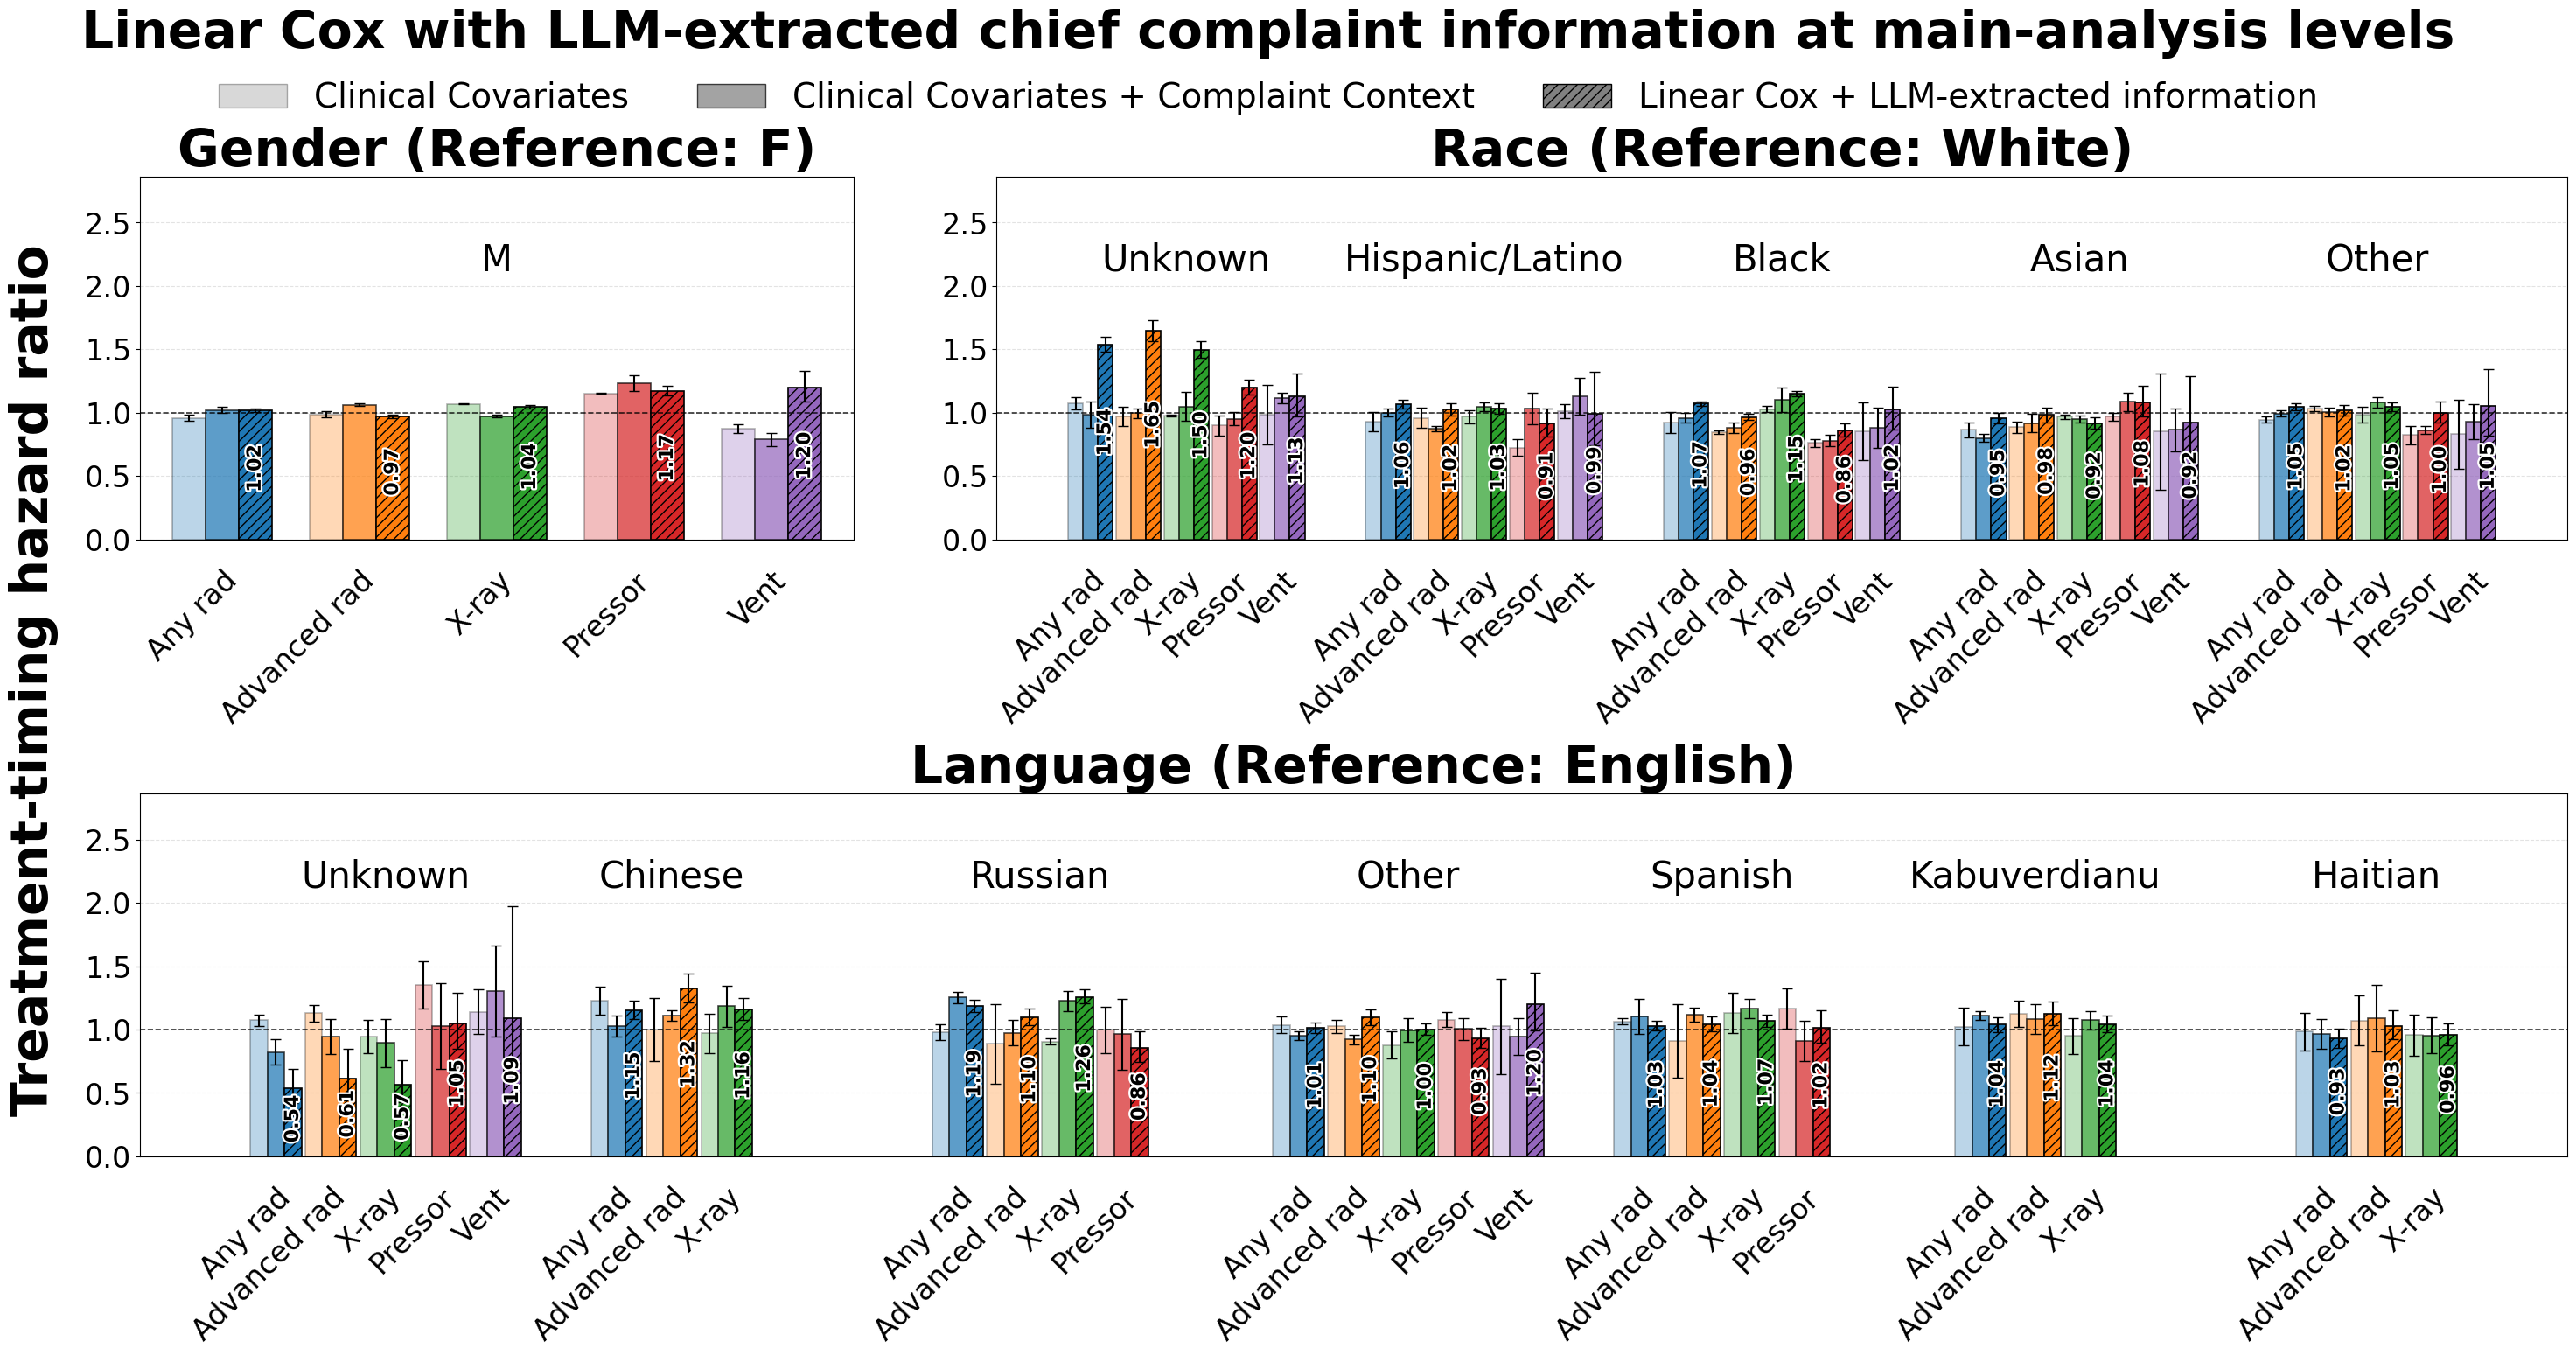

In [ ]:

import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch

VIS_OUT = FIG_DIR / 'linear_cox_llm_main_levels_disparity_plot'

outcome_order = [
    'time_to_any_rad_hours',
    'time_to_advanced_hours',
    'time_to_xray_hours',
    'time_to_pressor_hours',
    'time_to_vent_hours',
]
outcome_map = {
    'time_to_any_rad_hours': 'Any rad',
    'time_to_advanced_hours': 'Advanced rad',
    'time_to_xray_hours': 'X-ray',
    'time_to_pressor_hours': 'Pressor',
    'time_to_vent_hours': 'Vent',
}
outcome_to_color = dict(zip(outcome_order, plt.rcParams['axes.prop_cycle'].by_key()['color']))
group_order = ['gender', 'race', 'language']
group_title_map = {'gender': 'Gender', 'race': 'Race', 'language': 'Language'}


def _first_existing_path(paths):
    for p in paths:
        if p.exists():
            return p
    return None


def load_main_pipeline_compare_if_available() -> pd.DataFrame:
    rows = []
    candidates = {
        'radiology': [
            MAIN / 'radiology' / 'delete_a_group_jackknife' / 'jackknife_summary.parquet',
            MAIN / 'radiology' / 'main' / 'radiology_weighted_compare.parquet',
        ],
        'pressor': [
            MAIN / 'icu' / 'pressor' / 'delete_a_group_jackknife' / 'jackknife_summary.parquet',
            MAIN / 'icu' / 'pressor' / 'main' / 'pressor_weighted_compare.parquet',
        ],
        'vent': [
            MAIN / 'icu' / 'vent' / 'delete_a_group_jackknife' / 'jackknife_summary.parquet',
            MAIN / 'icu' / 'vent' / 'main' / 'vent_weighted_compare.parquet',
        ],
    }

    for dataset, paths in candidates.items():
        path = _first_existing_path(paths)
        if path is None:
            print(f'Main-pipeline compare file not found for {dataset}; plot will use linear-Cox bars only for this dataset.')
            continue
        df = pd.read_parquet(path).copy()
        df['dataset'] = dataset
        rows.append(df)
        print('Loaded main-pipeline comparison:', path)

    if not rows:
        return pd.DataFrame()
    out = pd.concat(rows, ignore_index=True)
    if 'family_var' not in out.columns and 'group_var' in out.columns:
        out['family_var'] = out['group_var']
    return out


def prep_plot_table(linear_compare: pd.DataFrame) -> pd.DataFrame:
    lin = linear_compare.copy()
    lin = lin.loc[lin['level'].ne(lin['ref_level'])].copy()

    main_cmp = load_main_pipeline_compare_if_available()
    if len(main_cmp) == 0:
        plot = lin.copy()
        plot['hr_base'] = np.nan
        plot['hr_text'] = np.nan
        plot['hr_base_lo'] = np.nan
        plot['hr_base_hi'] = np.nan
        plot['hr_text_lo'] = np.nan
        plot['hr_text_hi'] = np.nan
    else:
        keep_cols = ['dataset', 'outcome', 'family_var', 'group_var', 'level', 'ref_level', 'term']
        main_cols = keep_cols + [c for c in main_cmp.columns if c.startswith('HR_')]
        main_small = main_cmp.loc[:, [c for c in main_cols if c in main_cmp.columns]].copy()

        rename = {
            'HR_structured': 'hr_base',
            'HR_structured_plus_text': 'hr_text',
            'HR_structured_jackknife_ci_low': 'hr_base_lo',
            'HR_structured_jackknife_ci_high': 'hr_base_hi',
            'HR_structured_plus_text_jackknife_ci_low': 'hr_text_lo',
            'HR_structured_plus_text_jackknife_ci_high': 'hr_text_hi',
        }
        main_small = main_small.rename(columns={k: v for k, v in rename.items() if k in main_small.columns})
        for c in ['hr_base', 'hr_text', 'hr_base_lo', 'hr_base_hi', 'hr_text_lo', 'hr_text_hi']:
            if c not in main_small.columns:
                main_small[c] = np.nan

        plot = lin.merge(
            main_small,
            on=['dataset', 'outcome', 'family_var', 'group_var', 'level', 'ref_level', 'term'],
            how='left',
        )

    plot['hr_llm'] = plot['HR_linear_cox_llm']
    plot['hr_llm_lo'] = plot['ci_low_HR_linear_cox_llm']
    plot['hr_llm_hi'] = plot['ci_high_HR_linear_cox_llm']
    plot['outcome_label_short'] = plot['outcome'].map(outcome_map).fillna(plot['outcome'])
    plot['sort_key'] = np.nanmax(
        np.abs(np.log(plot[['hr_base', 'hr_text', 'hr_llm']].to_numpy(dtype=float))),
        axis=1,
    )
    plot['sort_key'] = plot['sort_key'].where(np.isfinite(plot['sort_key']), 0.0)
    return plot


plot_summ = prep_plot_table(linear_compare)
plot_summ.to_csv(OUT_DIR / 'linear_cox_llm_main_levels_plot_table.csv', index=False)

fig = plt.figure(figsize=(30, 16))
gs = GridSpec(2, 3, figure=fig)

gender_ax = fig.add_subplot(gs[0, 0])
race_ax = fig.add_subplot(gs[0, 1:3], sharey=gender_ax)
language_ax = fig.add_subplot(gs[1, 0:3], sharey=gender_ax)
axes = {'gender': gender_ax, 'race': race_ax, 'language': language_ax}

fig.subplots_adjust(left=0.07, right=0.995, bottom=0.16, top=0.86, wspace=0.20, hspace=0.70)

spacing_cfg = {
    'gender': {'bar_w': 0.14, 'outcome_gap': 0.58, 'label_gap': 1.10},
    'race': {'bar_w': 0.18, 'outcome_gap': 0.58, 'label_gap': 0.70},
    'language': {'bar_w': 0.18, 'outcome_gap': 0.58, 'label_gap': 0.70},
}

all_hi = []
for c in ['hr_base_hi', 'hr_text_hi', 'hr_llm_hi', 'hr_base', 'hr_text', 'hr_llm']:
    if c in plot_summ.columns:
        all_hi.extend(pd.to_numeric(plot_summ[c], errors='coerce').tolist())
all_hi = [v for v in all_hi if np.isfinite(v)]
global_ymax = max(all_hi) * 1.45 if all_hi else 2.0
global_ymax = max(global_ymax, 1.5)
level_label_y = global_ymax * 0.82

text_effects = [pe.Stroke(linewidth=3.2, foreground='white'), pe.Normal()]
model_specs_for_plot = [
    ('hr_base', 'hr_base_lo', 'hr_base_hi', 'Clinical Covariates', 0.30, ''),
    ('hr_text', 'hr_text_lo', 'hr_text_hi', 'Clinical Covariates + Complaint Context', 0.72, ''),
    ('hr_llm', 'hr_llm_lo', 'hr_llm_hi', 'Linear Cox + LLM-extracted information', 1.00, '///'),
]

for group_var in group_order:
    ax = axes[group_var]
    sub = plot_summ.loc[plot_summ['group_var'].eq(group_var)].copy()

    bar_w = spacing_cfg[group_var]['bar_w']
    outcome_gap = spacing_cfg[group_var]['outcome_gap']
    label_gap = spacing_cfg[group_var]['label_gap']

    term_order = (
        sub.groupby('term')['sort_key']
        .max()
        .sort_values(ascending=False)
        .index.tolist()
    )

    xticks = []
    xticklabels = []
    level_centers = []
    level_labels = []
    x_cursor = 0.0

    for term in term_order:
        term_df = sub.loc[sub['term'].eq(term)]
        outcome_positions_this_term = []

        for i_outcome, outcome in enumerate(outcome_order):
            row_df = term_df.loc[term_df['outcome'].eq(outcome)]
            if row_df.empty:
                continue
            row = row_df.iloc[0]
            c = outcome_to_color.get(outcome, 'gray')
            x0 = x_cursor + i_outcome * outcome_gap
            offsets = [-bar_w, 0.0, bar_w]

            for (metric, lo_col, hi_col, model_label, alpha, hatch), offset in zip(model_specs_for_plot, offsets):
                val = pd.to_numeric(row.get(metric, np.nan), errors='coerce')
                if not np.isfinite(val):
                    continue
                xpos = x0 + offset
                ax.bar(
                    xpos,
                    float(val),
                    width=bar_w,
                    color=c,
                    alpha=alpha,
                    hatch=hatch,
                    edgecolor='black',
                    linewidth=1.2,
                    zorder=2,
                )
                lo = pd.to_numeric(row.get(lo_col, np.nan), errors='coerce')
                hi = pd.to_numeric(row.get(hi_col, np.nan), errors='coerce')
                if np.isfinite(lo) and np.isfinite(hi):
                    ax.errorbar(
                        xpos,
                        float(val),
                        yerr=[[float(val - lo)], [float(hi - val)]],
                        fmt='none',
                        ecolor='black',
                        elinewidth=1.5,
                        capsize=4,
                        zorder=3,
                    )
                if metric == 'hr_llm':
                    label_y = max(float(val) * 0.55, 0.10)
                    ax.text(
                        xpos,
                        label_y,
                        f'{val:.2f}',
                        ha='center',
                        va='center',
                        rotation=90,
                        fontsize=16,
                        fontweight='bold',
                        path_effects=text_effects,
                        zorder=5,
                    )

            xticks.append(x0)
            xticklabels.append(outcome_map.get(outcome, outcome))
            outcome_positions_this_term.append(x0)

        if outcome_positions_this_term:
            level_centers.append(float(np.mean(outcome_positions_this_term)))
            level_labels.append(pretty_level_name(term, group_var))

        x_cursor += len(outcome_order) * outcome_gap + label_gap

    ax.set_title(f'{group_title_map[group_var]} (Reference: {REF[group_var]})', fontsize=42, fontweight='bold')
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, rotation=45, ha='right', rotation_mode='anchor', fontsize=24)
    ax.tick_params(axis='x', length=0, pad=22)
    ax.tick_params(axis='y', labelsize=24)
    ax.grid(axis='y', linestyle='--', linewidth=0.8, alpha=0.35)
    ax.set_axisbelow(True)
    ax.set_ylim(0, global_ymax)
    ax.axhline(1.0, linestyle='--', linewidth=1.2, color='black', alpha=0.8)

    for xpos, lbl in zip(level_centers, level_labels):
        ax.text(xpos, level_label_y, lbl, ha='center', va='top', fontsize=30)

for ax in axes.values():
    ax.set_ylabel('')

fig.supylabel('Treatment-timing hazard ratio', fontsize=42, fontweight='bold')
fig.suptitle('Linear Cox with LLM-extracted chief complaint information at main-analysis levels', fontsize=42, fontweight='bold')

legend_model = [
    Patch(facecolor='gray', edgecolor='black', alpha=0.30, label='Clinical Covariates'),
    Patch(facecolor='gray', edgecolor='black', alpha=0.72, label='Clinical Covariates + Complaint Context'),
    Patch(facecolor='gray', edgecolor='black', alpha=1.00, hatch='///', label='Linear Cox + LLM-extracted information'),
]

fig.legend(handles=legend_model, loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=3, frameon=False, fontsize=28)

fig.savefig(VIS_OUT.with_suffix('.pdf'), format='pdf', bbox_inches='tight')

plt.show()


In [9]:

# This notebook intentionally fits only five new models: one Linear Cox + LLM-extracted-information model per outcome.
# It does not refit Linear Cox structured-only parents, so there is no within-notebook incremental R² block test here.
# The disparity figure compares the two existing main-analysis bars against the new Linear Cox + LLM bar.

print('New Linear Cox models fit:', len(fit_summary))
print(fit_summary[['dataset', 'outcome_label', 'model', 'n', 'events', 'p', 'cox_snell_r2']].to_string(index=False))


New Linear Cox models fit: 5
  dataset                   outcome_label                         model      n  events  p  cox_snell_r2
radiology             Any radiology order linear_cox_plus_llm_extracted 203016  117540 59      0.130085
radiology        Advanced radiology order linear_cox_plus_llm_extracted 203016   55903 59      0.108503
radiology                     X-ray order linear_cox_plus_llm_extracted 203016   86845 59      0.160998
  pressor          Vasopressor initiation linear_cox_plus_llm_extracted  69223   15242 68      0.141686
     vent Invasive ventilation initiation linear_cox_plus_llm_extracted  34042    1667 65      0.025881


In [10]:
# Load main-analysis text embeddings / SVD text features.
# This cell reads the existing pipeline text bundles and attaches z_* columns to processed_datasets.
# It does not refit anything and does not write files.

from pathlib import Path
import numpy as np
import pandas as pd

EMBED_PREFIX = "z_"

def find_embedding_file(dataset_name: str) -> Path:
    candidates = [
        ROOT / "main" / "shared" / dataset_name / f"{dataset_name}_text_bundle.parquet",
        ROOT / "main" / "shared" / dataset_name / f"{dataset_name}_text_z.parquet",
        ROOT / "main" / "shared" / dataset_name / f"{dataset_name}_analytic_imputed.parquet",
    ]

    existing = [p for p in candidates if p.exists()]
    if not existing:
        raise FileNotFoundError(
            "No embedding/text feature file found for "
            f"{dataset_name}. Tried:\n" + "\n".join(map(str, candidates))
        )

    for p in existing:
        cols = pd.read_parquet(p).columns
        z_cols = [c for c in cols if str(c).startswith(EMBED_PREFIX)]
        if z_cols:
            return p

    raise ValueError(
        "Found files but none contained z_* embedding columns for "
        f"{dataset_name}. Existing files:\n" + "\n".join(map(str, existing))
    )


def load_embedding_frame(dataset_name: str) -> tuple[pd.DataFrame, list[str], Path]:
    path = find_embedding_file(dataset_name)
    emb = pd.read_parquet(path).reset_index(drop=True)
    emb_cols = [c for c in emb.columns if str(c).startswith(EMBED_PREFIX)]

    if len(emb_cols) == 0:
        raise ValueError(f"No {EMBED_PREFIX}* columns found in {path}")

    keep_cols = []
    for c in ["subject_id", "stay_id", "hadm_id"]:
        if c in emb.columns:
            keep_cols.append(c)

    out = emb.loc[:, keep_cols + emb_cols].copy()
    return out, emb_cols, path


def attach_embeddings_to_processed_datasets(processed_datasets: dict[str, pd.DataFrame]):
    embedding_store = {}
    embedding_cols_by_dataset = {}

    for dataset_name, df in processed_datasets.items():
        emb, emb_cols, emb_path = load_embedding_frame(dataset_name)

        print("\nDataset:", dataset_name)
        print("Embedding source:", emb_path)
        print("Embedding columns:", len(emb_cols))
        print("Processed rows:", len(df))
        print("Embedding rows:", len(emb))

        if len(emb) != len(df):
            merge_keys = [c for c in ["subject_id", "stay_id", "hadm_id"] if c in df.columns and c in emb.columns]
            if not merge_keys:
                raise ValueError(
                    f"Row count mismatch for {dataset_name} and no merge keys available: "
                    f"processed={len(df)}, embedding={len(emb)}"
                )

            print("Row count mismatch. Merging on:", merge_keys)
            before = len(df)
            merged = df.merge(
                emb.loc[:, merge_keys + emb_cols],
                on=merge_keys,
                how="left",
                validate="one_to_one" if len(emb[merge_keys].drop_duplicates()) == len(emb) else "many_to_one",
            )

            if len(merged) != before:
                raise ValueError(
                    f"Merge changed row count for {dataset_name}: before={before}, after={len(merged)}"
                )

            processed_datasets[dataset_name] = merged
        else:
            overlap = [c for c in emb_cols if c in df.columns]
            if overlap:
                df = df.drop(columns=overlap)

            processed_datasets[dataset_name] = pd.concat(
                [df.reset_index(drop=True), emb.loc[:, emb_cols].reset_index(drop=True)],
                axis=1,
            )

        attached = processed_datasets[dataset_name]
        missing_counts = attached[emb_cols].isna().sum()
        print("Rows with any missing embedding:", int(attached[emb_cols].isna().any(axis=1).sum()))
        print("Embedding finite:", bool(np.isfinite(attached[emb_cols].to_numpy(dtype=float)).all()))

        if missing_counts.sum() > 0:
            print("Top missing embedding columns:")
            print(missing_counts.sort_values(ascending=False).head(10).to_string())

        embedding_store[dataset_name] = attached.loc[:, emb_cols].copy()
        embedding_cols_by_dataset[dataset_name] = emb_cols

    return processed_datasets, embedding_store, embedding_cols_by_dataset


processed_datasets, embedding_store, embedding_cols_by_dataset = attach_embeddings_to_processed_datasets(processed_datasets)

print("\nLoaded embedding columns by dataset:")
for dataset_name, cols in embedding_cols_by_dataset.items():
    print(dataset_name, len(cols), cols[:5], "..." if len(cols) > 5 else "")


Dataset: radiology
Embedding source: main/shared/radiology/radiology_text_bundle.parquet
Embedding columns: 20
Processed rows: 203016
Embedding rows: 203016
Rows with any missing embedding: 0
Embedding finite: True

Dataset: pressor
Embedding source: main/shared/pressor/pressor_text_bundle.parquet
Embedding columns: 20
Processed rows: 69223
Embedding rows: 69223
Rows with any missing embedding: 0
Embedding finite: True

Dataset: vent
Embedding source: main/shared/vent/vent_text_bundle.parquet
Embedding columns: 20
Processed rows: 34042
Embedding rows: 34042
Rows with any missing embedding: 0
Embedding finite: True

Loaded embedding columns by dataset:
radiology 20 ['z_00', 'z_01', 'z_02', 'z_03', 'z_04'] ...
pressor 20 ['z_00', 'z_01', 'z_02', 'z_03', 'z_04'] ...
vent 20 ['z_00', 'z_01', 'z_02', 'z_03', 'z_04'] ...



Dataset: radiology
  n: 203016
  LLM predictor columns: 25
  embedding columns: 20
  CV: GroupKFold
  Model: HistGradientBoosting
    fold 1: train=162412, test=40604
    fold 2: train=162413, test=40603
    fold 3: train=162413, test=40603
    fold 4: train=162413, test=40603
    fold 5: train=162413, test=40603

Dataset: pressor
  n: 69223
  LLM predictor columns: 25
  embedding columns: 20
  CV: GroupKFold
  Model: HistGradientBoosting
    fold 1: train=55378, test=13845
    fold 2: train=55378, test=13845
    fold 3: train=55378, test=13845
    fold 4: train=55379, test=13844
    fold 5: train=55379, test=13844

Dataset: vent
  n: 34042
  LLM predictor columns: 25
  embedding columns: 20
  CV: GroupKFold
  Model: HistGradientBoosting
    fold 1: train=27233, test=6809
    fold 2: train=27233, test=6809
    fold 3: train=27234, test=6808
    fold 4: train=27234, test=6808
    fold 5: train=27234, test=6808

HistGradientBoosting embedding predictability summary
  dataset            

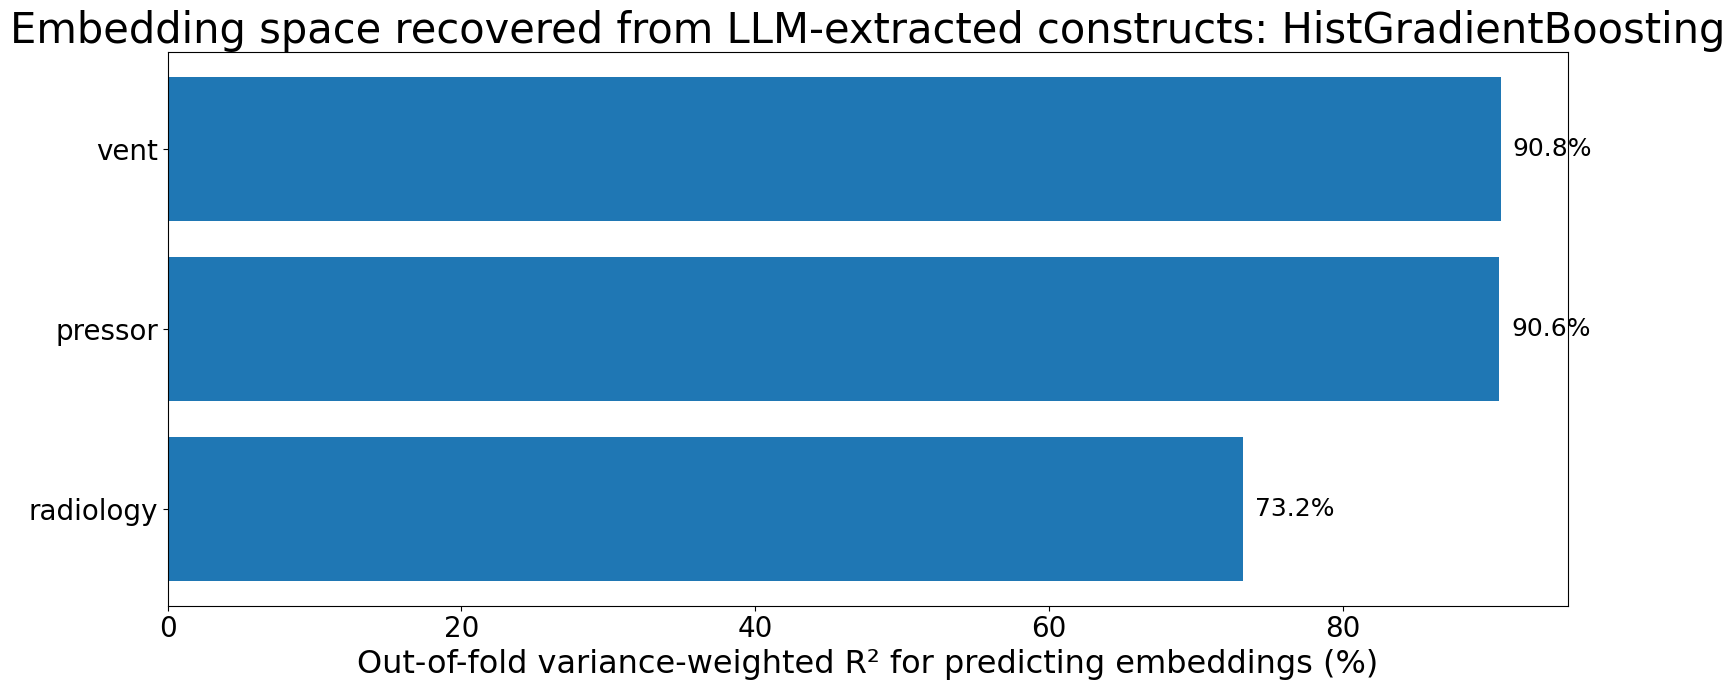

In [ ]:
# Construct validity sensitivity: HistGradientBoosting only.
# Predict embedding dimensions from LLM-extracted constructs using out-of-fold prediction.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import KFold, GroupKFold

TITLE_FS = globals().get("TITLE_FS", 30)
LABEL_FS = globals().get("LABEL_FS", 23)
TICK_FS = globals().get("TICK_FS", 20)

def _unique_existing_hgb(df, cols):
    out = []
    for c in cols:
        if c in df.columns and c not in out:
            out.append(c)
    return out

def _finite_matrix_hgb(name, arr):
    arr = np.asarray(arr, dtype=float)
    if not np.isfinite(arr).all():
        bad_n = int((~np.isfinite(arr)).sum())
        raise ValueError(f"{name} contains non-finite values: {bad_n}")
    return arr

def _make_cv_hgb(df, n_splits=5, group_col="subject_id"):
    if group_col in df.columns:
        groups = df[group_col].astype("string").to_numpy()
        n_groups = pd.Series(groups).nunique()
        if n_groups >= n_splits:
            return GroupKFold(n_splits=n_splits), groups
    return KFold(n_splits=n_splits, shuffle=True, random_state=20260207), None

def _variance_weighted_r2_hgb(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    sse = np.sum((y_true - y_pred) ** 2, axis=0)
    sst = np.sum((y_true - y_true.mean(axis=0, keepdims=True)) ** 2, axis=0)

    raw_r2 = np.divide(
        1.0 - sse / sst,
        1.0,
        out=np.full(y_true.shape[1], np.nan),
        where=sst > 0,
    )

    weights = sst / np.sum(sst)
    overall = float(np.nansum(weights * raw_r2))
    return overall, raw_r2, weights

def _oof_predict_hgb(model, X, Y, cv, groups=None):
    pred = np.full_like(Y, np.nan, dtype=float)
    splits = cv.split(X, Y, groups) if groups is not None else cv.split(X, Y)

    for fold_id, (train_idx, test_idx) in enumerate(splits, start=1):
        m = clone(model)
        m.fit(X[train_idx], Y[train_idx])
        pred[test_idx] = m.predict(X[test_idx])
        print(f"    fold {fold_id}: train={len(train_idx)}, test={len(test_idx)}", flush=True)

    if not np.isfinite(pred).all():
        raise ValueError("OOF predictions contain non-finite values")
    return pred

hgb_model_name = "HistGradientBoosting"
hgb_model = MultiOutputRegressor(
    HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.06,
        max_leaf_nodes=31,
        min_samples_leaf=30,
        l2_regularization=0.01,
        random_state=20260207,
    ),
    n_jobs=-1,
)

hgb_summary_rows = []
hgb_dim_rows = []

for dataset_name, df in processed_datasets.items():
    if dataset_name not in embedding_cols_by_dataset:
        raise ValueError(f"Missing embedding columns for {dataset_name}")

    z_cols = embedding_cols_by_dataset[dataset_name]
    x_cols = _unique_existing_hgb(df, list(CONSTRUCT_COLS) + ["clarity_score"])

    if len(x_cols) == 0:
        raise ValueError(f"No LLM-extracted predictor columns found for {dataset_name}")
    if len(z_cols) == 0:
        raise ValueError(f"No embedding columns found for {dataset_name}")

    X = _finite_matrix_hgb(f"{dataset_name} LLM predictors", df[x_cols].to_numpy(dtype=float))
    Y = _finite_matrix_hgb(f"{dataset_name} embeddings", df[z_cols].to_numpy(dtype=float))

    cv, groups = _make_cv_hgb(df, n_splits=5, group_col="subject_id")

    print("\nDataset:", dataset_name, flush=True)
    print("  n:", X.shape[0], flush=True)
    print("  LLM predictor columns:", len(x_cols), flush=True)
    print("  embedding columns:", len(z_cols), flush=True)
    print("  CV:", type(cv).__name__, flush=True)
    print("  Model:", hgb_model_name, flush=True)

    pred = _oof_predict_hgb(hgb_model, X, Y, cv, groups=groups)
    overall_r2, raw_r2, variance_weights = _variance_weighted_r2_hgb(Y, pred)

    hgb_summary_rows.append({
        "dataset": dataset_name,
        "model": hgb_model_name,
        "n": int(X.shape[0]),
        "n_llm_predictors": int(X.shape[1]),
        "n_embedding_dims": int(Y.shape[1]),
        "variance_weighted_cv_r2": overall_r2,
        "mean_dim_cv_r2": float(np.nanmean(raw_r2)),
        "median_dim_cv_r2": float(np.nanmedian(raw_r2)),
        "min_dim_cv_r2": float(np.nanmin(raw_r2)),
        "max_dim_cv_r2": float(np.nanmax(raw_r2)),
    })

    for j, col in enumerate(z_cols):
        hgb_dim_rows.append({
            "dataset": dataset_name,
            "model": hgb_model_name,
            "embedding_col": col,
            "cv_r2": float(raw_r2[j]),
            "embedding_variance_weight": float(variance_weights[j]),
        })

hgb_embedding_cv_summary = pd.DataFrame(hgb_summary_rows)
hgb_embedding_cv_by_dimension = pd.DataFrame(hgb_dim_rows)

print("\nHistGradientBoosting embedding predictability summary")
print(hgb_embedding_cv_summary.to_string(index=False))

plot_df = hgb_embedding_cv_summary.sort_values("variance_weighted_cv_r2").copy()

fig, ax = plt.subplots(figsize=(16, max(7, 0.8 * len(plot_df))))
y = np.arange(len(plot_df))
vals = 100.0 * plot_df["variance_weighted_cv_r2"].to_numpy(dtype=float)

ax.barh(y, vals)
ax.set_yticks(y)
ax.set_yticklabels(plot_df["dataset"], fontsize=TICK_FS)
ax.tick_params(axis="x", labelsize=TICK_FS)
ax.set_xlabel("Out-of-fold variance-weighted R² for predicting embeddings (%)", fontsize=LABEL_FS)
ax.set_title("Embedding space recovered from LLM-extracted constructs: HistGradientBoosting", fontsize=TITLE_FS)

for i, v in enumerate(vals):
    ax.text(v + 0.8, i, f"{v:.1f}%", va="center", fontsize=18)

fig.tight_layout()
fig.savefig(FIG_DIR / "hgb_embedding_cv_r2.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Outputs

Main files:

- `linear_cox_main_levels_coefficients.csv/parquet`
- `linear_cox_main_levels_compare.csv/parquet`
- `linear_cox_main_levels_fit_summary.csv/parquet`
- `linear_cox_llm_main_levels_plot_table.csv`

Main figures:

- `figures/linear_cox_llm_main_levels_disparity_plot.pdf/png`

This notebook fits exactly five new models: one `Linear Cox + LLM-extracted information` model per outcome. The first two bars in the disparity plot are loaded from the existing main-analysis outputs; they are not refit.
